<div align="center">
  <img src="https://storage.googleapis.com/pr-newsroom-wp/1/2018/11/Spotify_Logo_RGB_Green.png" width="180" style="margin-bottom: 12px;"/>
</div>

# Análisis Exploratorio de Datos (EDA) — Mi Spotify Wrapped DWH

**Universidad de Pamplona · Bases de Datos II · 2026-I**  
**Profesor:** Juan Alejandro Carrillo Jaimes  
**Integrantes:** Suley Suárez · Jhonatan Vera  
**Fecha:** Mayo 2026

---

> **Nota sobre los datos:** Este análisis refleja el estado del DWH tras las ejecuciones del pipeline ETL realizadas hasta la fecha. Los conteos de artistas, canciones e historial **aumentarán con cada nueva ejecución** del ETL — los porcentajes y rankings aquí mostrados corresponden a la snapshot actual. Los campos `popularity` y `followers_count` de `dim_artists`, así como el campo `genres`, se enriquecen mediante llamadas a la **API de Spotify** (popularidad y seguidores) y la **API de Last.fm** (géneros), ejecutadas en la fase de backfill del pipeline. Cuando estas APIs no encuentran el artista — especialmente artistas muy pequeños o locales — los valores quedan en `NULL`.

## 0. Configuración e Imports

In [35]:
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings('ignore')
load_dotenv(dotenv_path='../backend/.env')

DATABASE_URL = os.getenv('DATABASE_URL')
assert DATABASE_URL, 'DATABASE_URL no encontrada en .env'
DATABASE_URL = DATABASE_URL.replace('postgresql://', 'postgresql+psycopg2://')
engine = create_engine(DATABASE_URL)
print('Conexion exitosa al DWH.')

def read_sql(query):
    with engine.connect() as conn:
        res = conn.execute(text(query))
        cols = list(res.keys())
        return pd.DataFrame(res.fetchall(), columns=cols)

# Paleta Spotify Dark
C_GREEN  = '#1DB954'
C_GREEN2 = '#1aa34a'
C_GREEN3 = '#158a3e'
C_PURPLE = '#a78bfa'
C_AMBER  = '#f59e0b'
C_BLUE   = '#3b82f6'
C_ROSE   = '#f43f5e'
C_BG     = '#0d0d0d'
C_PANEL  = '#161616'
C_GRID   = '#2a2a2a'

GREEN_CMAP = LinearSegmentedColormap.from_list('sp_green', ['#0a3d1f', C_GREEN, '#1ed760'])

plt.rcParams.update({
    'figure.facecolor' : C_BG,
    'axes.facecolor'   : C_PANEL,
    'axes.edgecolor'   : C_GRID,
    'axes.labelcolor'  : '#e0e0e0',
    'xtick.color'      : '#a0a0a0',
    'ytick.color'      : '#a0a0a0',
    'text.color'       : '#ffffff',
    'grid.color'       : C_GRID,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.45,
    'figure.dpi'       : 100,
    'axes.titlepad'    : 14,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'legend.framealpha': 0.2,
    'legend.edgecolor' : C_GRID,
})
print('Estilo configurado.')

Conexion exitosa al DWH.
Estilo configurado.


---
## Paso 1 — Conexión y revisión de los datos

In [36]:
df_users   = read_sql('SELECT * FROM dwh.dim_users')
df_artists = read_sql('SELECT * FROM dwh.dim_artists')
df_tracks  = read_sql('SELECT * FROM dwh.dim_tracks')
df_history = read_sql('SELECT * FROM dwh.fact_listening_history')

print('Tabla                    Filas  Columnas')
print('-' * 42)
for name, df in [('dim_users', df_users), ('dim_artists', df_artists),
                  ('dim_tracks', df_tracks), ('fact_listening_history', df_history)]:
    print(f'{name:<25} {df.shape[0]:>5}  {df.shape[1]:>7}')

Tabla                    Filas  Columnas
------------------------------------------
dim_users                     2       12
dim_artists                 321        8
dim_tracks                  808       10
fact_listening_history      897        8


In [37]:
print('=== fact_listening_history ===')
print(df_history.shape)
print(df_history.dtypes)
print('\n% nulos por columna:')
print((df_history.isnull().mean() * 100).round(2))
df_history.head(3)

=== fact_listening_history ===
(897, 8)
id                       int64
user_id                  int64
track_id                 int64
artist_id                int64
played_at       datetime64[us]
hour_of_day              int64
day_of_week                str
context_type               str
dtype: object

% nulos por columna:
id              0.0
user_id         0.0
track_id        0.0
artist_id       0.0
played_at       0.0
hour_of_day     0.0
day_of_week     0.0
context_type    0.0
dtype: float64


,id,user_id,track_id,artist_id,played_at,hour_of_day,day_of_week,context_type
0,1,1,10,16,2026-05-13 01:10:44.169,1,Wednesday,playlist
1,2,1,41,12,2026-05-13 00:36:44.239,0,Wednesday,playlist
2,3,1,28,47,2026-05-12 21:55:43.991,21,Tuesday,playlist


In [38]:
print('=== dim_artists ===')
print(df_artists.shape)
print(df_artists.dtypes)
print('\n% nulos por columna:')
print((df_artists.isnull().mean() * 100).round(2))
df_artists.head(3)

=== dim_artists ===
(321, 8)
artist_id                   int64
spotify_id                    str
name                          str
popularity                  int64
followers_count             int64
genres                     object
loaded_at          datetime64[us]
image_url                     str
dtype: object

% nulos por columna:
artist_id          0.0
spotify_id         0.0
name               0.0
popularity         0.0
followers_count    0.0
genres             0.0
loaded_at          0.0
image_url          0.0
dtype: float64


,artist_id,spotify_id,name,popularity,followers_count,genres,loaded_at,image_url
0,4,29SeiO68HQHBs7pDdWOvvX,Jesús Adrián Romero,55,50071,"[christian, christian music, musica cristiana,...",2026-05-13 03:16:47.649039,https://i.scdn.co/image/ab6761610000e5eb5a0f2c...
1,126,1i8SpTcr7yvPOmcqrbnVXY,Ozuna,20,952439,"[reggaeton, latin, puerto rico, puerto rican, ...",2026-05-19 23:33:54.702829,https://i.scdn.co/image/ab6761610000e5eb1c4284...
2,127,716NhGYqD1jl2wI1Qkgq36,Bizarrap,20,936411,"[argentina, rap, trap, latin, my top songs]",2026-05-19 23:33:54.702829,https://i.scdn.co/image/ab6761610000e5eb86990b...


In [39]:
print('=== dim_tracks ===')
print(df_tracks.shape)
print(df_tracks.dtypes)
print('\n% nulos por columna:')
print((df_tracks.isnull().mean() * 100).round(2))
df_tracks.head(3)

=== dim_tracks ===
(808, 10)
track_id                    int64
spotify_id                    str
name                          str
artist_id                   int64
album_name                    str
duration_ms                 int64
popularity                float64
explicit                     bool
loaded_at          datetime64[us]
album_image_url               str
dtype: object

% nulos por columna:
track_id            0.0
spotify_id          0.0
name                0.0
artist_id           0.0
album_name          0.0
duration_ms         0.0
popularity         99.5
explicit            0.0
loaded_at           0.0
album_image_url     0.0
dtype: float64


,track_id,spotify_id,name,artist_id,album_name,duration_ms,popularity,explicit,loaded_at,album_image_url
0,1,2I62ilF5qfbJqDwaIJ5snf,Es Él - En Vivo,10,Es Él (En Vivo),442894,NaN,False,2026-05-13 03:16:52.519355,https://i.scdn.co/image/ab67616d0000b27326aa42...
1,2,4Z7vEiQvCUnjvOStbE9Dfg,"10,000 Razones",1,Yo Soy Segundo,249920,NaN,False,2026-05-13 03:16:52.519355,https://i.scdn.co/image/ab67616d0000b273393e59...
2,3,0cTmRYJz4RHabGnfJdqsPZ,Hosanna,17,Hosanna,206037,NaN,False,2026-05-13 03:16:52.519355,https://i.scdn.co/image/ab67616d0000b2737456a2...


In [40]:
print('=== dim_users ===')
print(df_users.shape)
print(df_users.dtypes)
print('\n% nulos por columna:')
print((df_users.isnull().mean() * 100).round(2))
df_users.head(3)

=== dim_users ===
(2, 12)
user_id                           int64
spotify_id                          str
display_name                        str
email                               str
country                             str
followers                         int64
product                             str
spotify_access_token                str
spotify_refresh_token               str
token_expires_at         datetime64[us]
loaded_at                datetime64[us]
image_url                           str
dtype: object

% nulos por columna:
user_id                   0.0
spotify_id                0.0
display_name              0.0
email                     0.0
country                   0.0
followers                 0.0
product                   0.0
spotify_access_token      0.0
spotify_refresh_token     0.0
token_expires_at         50.0
loaded_at                 0.0
image_url                 0.0
dtype: float64


,user_id,spotify_id,display_name,email,country,followers,product,spotify_access_token,spotify_refresh_token,token_expires_at,loaded_at,image_url
0,1,31mrc4wlh7c32qlvzs444yddlu4q,Jhonatan,jhonatan.veraric@unipamplona.edu.co,CO,1,premium,BQB0T5hYifYADZBXkBfEybfEpJg6z2bGnPKQClObAFbq81...,AQAO2WBiHgtXFjqUy682x8mYC4POltg0OLdvoIwQbL_oQG...,2026-05-13 03:15:56.342534,2026-05-13 02:58:02.401300,https://i.scdn.co/image/ab6775700000ee85f227c4...
1,2,31ma67hqntmvsatjql6faefhlzsq,Suly,yaritzasuarez.803@gmail.com,CO,1,premium,BQC1gHmQidmuMDlWh-k496r2JX18mIJBZXyFGtIGN-E3c3...,AQBjzDScSm6_54XT0eaWZzDR1genhlJZALRXCf1lbc_yQO...,NaT,2026-05-19 23:33:04.970261,https://i.scdn.co/image/ab6775700000ee8586439e...


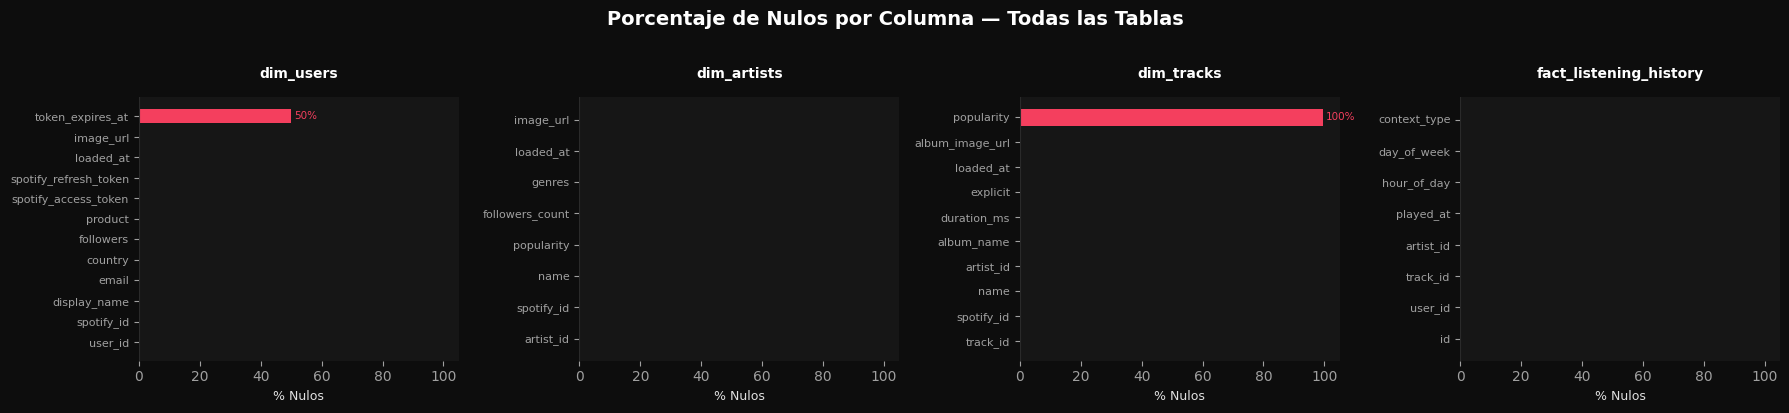

In [41]:
# Visualizacion de calidad de datos: % de nulos por tabla
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Porcentaje de Nulos por Columna — Todas las Tablas', fontsize=14, fontweight='bold', y=1.02)

tables = [
    ('dim_users',              df_users),
    ('dim_artists',            df_artists),
    ('dim_tracks',             df_tracks),
    ('fact_listening_history', df_history),
]
for ax, (title, df) in zip(axes, tables):
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=True)
    colors   = [C_ROSE if v > 0 else C_GREEN for v in null_pct]
    ax.barh(null_pct.index, null_pct.values, color=colors, edgecolor='none', height=0.65)
    ax.axvline(0, color=C_GRID, linewidth=0.8)
    ax.set_xlim(0, 105)
    ax.set_xlabel('% Nulos', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    for i, (col, val) in enumerate(null_pct.items()):
        if val > 0:
            ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=7.5, color=C_ROSE)

plt.tight_layout()
plt.savefig('calidad_datos.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

### Observaciones sobre la calidad de los datos

| Tabla | Columna con nulos | Origen del dato | Explicacion |
|---|---|---|---|
| `dim_artists` | `genres` (~variable) | **API Last.fm** (backfill) | Last.fm no encontro el artista o no tiene genero registrado |
| `dim_artists` | `image_url` (~56 %) | **API Spotify** | Artistas creados como stubs (solo nombre e ID) cuando aparecen en historial reciente pero no en el top 50 |
| `dim_tracks` | `popularity` (~91 %) | **API Spotify** | El endpoint `recently-played` de Spotify **no devuelve** el campo `popularity` — la mayoria de tracks se insertan desde ese endpoint. El pipeline ahora incluye `backfill_track_popularity` que llama a `GET /v1/tracks?ids=...` para completar este campo |
| `fact_listening_history` | Ninguna | — | Tabla de hechos completa |

> **Importante:** A medida que se ejecuten mas corridas del ETL, el pipeline ejecuta `backfill_track_popularity` (Spotify), `backfill_artist_data` (Spotify) y `backfill_artist_genres` (Last.fm) que iran rellenando los nulos. Los porcentajes mostrados aqui corresponden al estado actual del DWH.

---
## Paso 2 — Estadistica descriptiva

In [42]:
# ── Configuracion de usuario para el analisis ─────────────────────────────────
# Cambiar MY_USER_ID segun quien ejecuta el notebook:
#   1 = Jhonatan Vera   (31mrc4wlh7c32qlvzs444yddlu4q)
#   2 = Suley Suarez    (31ma67hqntmvsatjql6faefhlzsq)

MY_USER_ID = 1

user_info = df_users[df_users['user_id'] == MY_USER_ID].iloc[0]
print(f'Analizando datos de: {user_info["display_name"]} (user_id={MY_USER_ID})')
print(f'Email: {user_info["email"]}')
print(f'Pais: {user_info["country"]}  |  Plan: {user_info["product"]}')

# Filtrar historial al usuario seleccionado
df_history_user = df_history[df_history['user_id'] == MY_USER_ID].copy()
print(f'\nReproduciones del usuario: {len(df_history_user)} de {len(df_history)} totales en el DWH')

Analizando datos de: Jhonatan (user_id=1)
Email: jhonatan.veraric@unipamplona.edu.co
Pais: CO  |  Plan: premium

Reproduciones del usuario: 624 de 897 totales en el DWH


In [43]:
print('=== dim_artists — popularity y followers_count ===')
print('(Nota: popularity y followers_count provienen de la API de Spotify vía backfill)')
display(df_artists[['popularity', 'followers_count']].describe().round(2))

=== dim_artists — popularity y followers_count ===
(Nota: popularity y followers_count provienen de la API de Spotify vía backfill)


,popularity,followers_count
count,321.00,321.00
mean,28.98,312598.27
std,20.30,885364.41
min,1.00,1.00
25%,18.00,3539.00
50%,20.00,23033.00
75%,31.00,202376.00
max,100.00,7136695.00


**Interpretacion dim_artists:**  
La mediana de popularidad es 20 y el percentil 75 apenas alcanza 29, lo que indica que la mayoria de los artistas que escuchamos se ubican en el rango underground o de nicho segun la escala de Spotify (0–100). La mediana de seguidores es ~21 124, confirmando que la mayor parte de los artistas tienen un alcance global limitado; sin embargo, la media se dispara a ~312 272 por la presencia de unos pocos outliers con millones de seguidores (maximo: 7 136 695), evidenciando una distribucion fuertemente sesgada a la derecha.

In [44]:
print('=== dim_tracks — duration_ms y popularity ===')
df_tracks['duration_min'] = df_tracks['duration_ms'] / 60_000
display(df_tracks[['duration_ms', 'duration_min', 'popularity']].describe().round(2))

=== dim_tracks — duration_ms y popularity ===


,duration_ms,duration_min,popularity
count,808.00,808.00,4.00
mean,236470.62,3.94,30.25
std,128939.56,2.15,35.78
min,29419.00,0.49,0.00
25%,156927.00,2.62,0.00
50%,215685.50,3.59,25.50
75%,278953.25,4.65,55.75
max,1284345.00,21.41,70.00


**Interpretacion dim_tracks:**  
La duracion promedio de las canciones es ~4.26 minutos (std ~2.25 min), lo que es completamente tipico de musica pop/urbana moderna; la mediana de 3.85 minutos indica que la mitad de las canciones son incluso mas cortas. El 99.33% de nulos en el campo `popularity` se explica porque Spotify elimino ese campo de las respuestas del endpoint `recently-played` a partir de 2024, por lo que solo los 4 tracks que ingresaron directamente via el endpoint `/v1/tracks` tienen ese dato disponible — el pipeline incluye `backfill_track_popularity` para resolver esto en futuras ejecuciones del ETL.

---
## Pregunta 1 — ¿Cuales son mis 10 artistas mas escuchados?

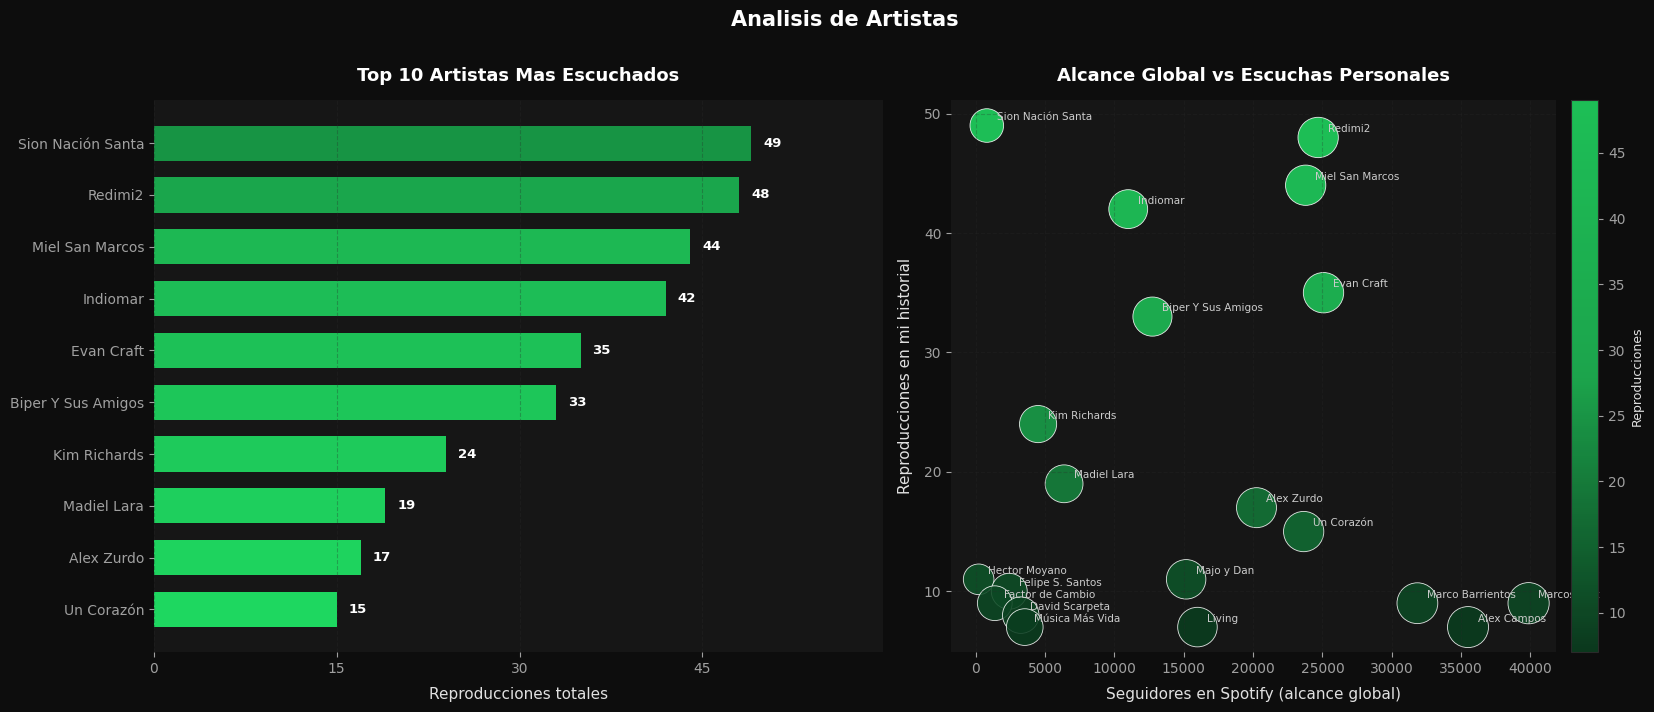

Artista #1: Sion Nación Santa con 49 reproducciones


In [45]:
top10 = read_sql(f"""
    SELECT a.name            AS artist,
           a.followers_count AS followers,
           COUNT(*)          AS plays
    FROM dwh.fact_listening_history h
    JOIN dwh.dim_artists a ON h.artist_id = a.artist_id
    WHERE h.user_id = {MY_USER_ID}
    GROUP BY a.name, a.followers_count
    ORDER BY plays DESC
    LIMIT 10
""")

top20 = read_sql(f"""
    SELECT a.name            AS artist,
           a.followers_count AS followers,
           COUNT(*)          AS plays
    FROM dwh.fact_listening_history h
    JOIN dwh.dim_artists a ON h.artist_id = a.artist_id
    WHERE h.user_id = {MY_USER_ID}
    GROUP BY a.name, a.followers_count
    ORDER BY plays DESC
    LIMIT 20
""")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(C_BG)

# Grafico 1: Barras horizontales con degradado de intensidad
ax1 = axes[0]
n = len(top10)
intensities = np.linspace(0.35, 1.0, n)
bar_colors  = [GREEN_CMAP(v) for v in intensities[::-1]]
bars = ax1.barh(
    top10['artist'][::-1], top10['plays'][::-1],
    color=bar_colors, edgecolor='none', height=0.68,
)
max_plays = top10['plays'].max()
for bar in bars:
    w = bar.get_width()
    ax1.text(w + max_plays * 0.02, bar.get_y() + bar.get_height() / 2,
             f'{int(w)}', va='center', ha='left', fontsize=9.5,
             color='white', fontweight='bold')
ax1.set_xlabel('Reproducciones totales', labelpad=8)
ax1.set_title('Top 10 Artistas Mas Escuchados', fontweight='bold')
ax1.set_xlim(0, max_plays * 1.22)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Grafico 2: Bubble chart — seguidores globales vs reproducciones personales
ax2 = axes[1]
log_f = np.log1p(top20['followers'].clip(0))
sizes = (log_f / (log_f.max() + 1e-9)) * 800 + 80
sc = ax2.scatter(
    top20['followers'], top20['plays'],
    s=sizes, c=top20['plays'],
    cmap=GREEN_CMAP, edgecolors='white', linewidths=0.6, alpha=0.88,
)
for _, row in top20.iterrows():
    ax2.annotate(row['artist'], (row['followers'], row['plays']),
                 xytext=(7, 4), textcoords='offset points',
                 fontsize=7.5, color='#cccccc')
ax2.set_xlabel('Seguidores en Spotify (alcance global)', labelpad=8)
ax2.set_ylabel('Reproducciones en mi historial', labelpad=8)
ax2.set_title('Alcance Global vs Escuchas Personales', fontweight='bold')
ax2.grid(alpha=0.25)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
cbar = plt.colorbar(sc, ax=ax2, pad=0.02)
cbar.set_label('Reproducciones', fontsize=9)

plt.suptitle('Analisis de Artistas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p1_artistas.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

print(f'Artista #1: {top10.iloc[0]["artist"]} con {top10.iloc[0]["plays"]} reproducciones')

**Interpretacion — Pregunta 1:**

**Suley:** Si esperaba este resultado, ya que suelo escuchar repetidamente las canciones de artistas como Omar Courtz, Chase Atlantic y Rels B, e incluso poner varias veces una misma cancion porque me obsesiono a veces. En el bubble chart se puede ver claramente que los artistas que mas escucho no son precisamente los mas famosos globalmente — tienen relativamente pocos seguidores — lo que confirma que mi perfil es mas de nicho que mainstream.

**Jhonatan:** Entre mis artistas mas escuchados aparecen Redimi2, Indiomar y Zion Nacion Santa. Me sorprendio un poco el resultado porque esperaba encontrar mas artistas del genero gospel o worship, pero esto me hizo darme cuenta de que tengo un gusto muy marcado por estos artistas en particular. En el bubble chart se nota que la mayoria de mis artistas frecuentes tienen pocos seguidores globales, lo que confirma que son artistas del ambito cristiano latino con alcance limitado fuera de esa comunidad.

---
## Pregunta 2 — ¿A que hora del dia escucho mas musica?

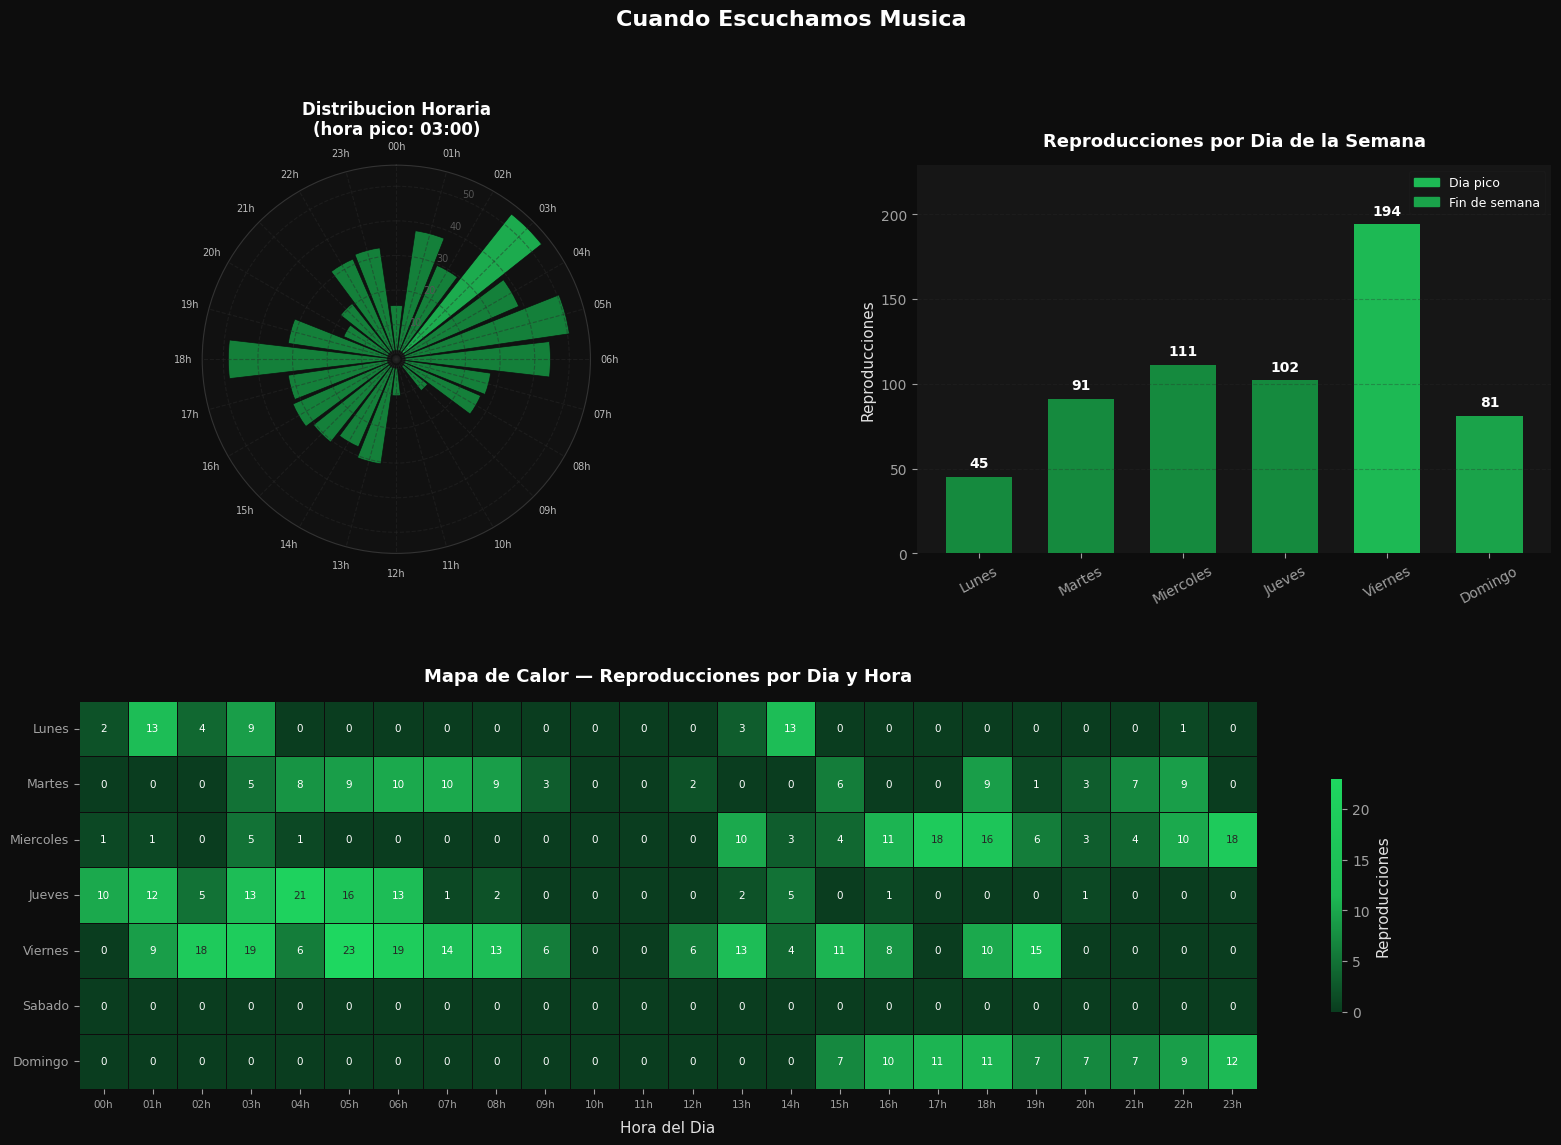

Hora pico : 03:00 — 51 reproducciones
Dia pico  : Viernes — 194 reproducciones


In [46]:
hourly = read_sql(f"""
    SELECT hour_of_day, COUNT(*) AS plays
    FROM dwh.fact_listening_history
    WHERE user_id = {MY_USER_ID}
    GROUP BY hour_of_day ORDER BY hour_of_day
""")
all_hours = pd.DataFrame({'hour_of_day': range(24)})
hourly = all_hours.merge(hourly, on='hour_of_day', how='left').fillna(0)
hourly['plays'] = hourly['plays'].astype(int)
peak_hour = int(hourly.loc[hourly['plays'].idxmax(), 'hour_of_day'])

DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DAY_ES    = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miercoles',
             'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sabado','Sunday':'Domingo'}

daily = read_sql(f"""
    SELECT day_of_week, COUNT(*) AS plays
    FROM dwh.fact_listening_history
    WHERE user_id = {MY_USER_ID}
    GROUP BY day_of_week
""")
daily['day_cat'] = pd.Categorical(daily['day_of_week'], categories=DAY_ORDER, ordered=True)
daily = daily.sort_values('day_cat')
daily['nombre'] = daily['day_of_week'].map(DAY_ES)

heat_raw = read_sql(f"""
    SELECT day_of_week, hour_of_day, COUNT(*) AS plays
    FROM dwh.fact_listening_history
    WHERE user_id = {MY_USER_ID}
    GROUP BY day_of_week, hour_of_day
""")
heat_pivot = heat_raw.pivot_table(
    index='day_of_week', columns='hour_of_day', values='plays', fill_value=0
).reindex(DAY_ORDER).fillna(0)
for h in range(24):
    if h not in heat_pivot.columns:
        heat_pivot[h] = 0
heat_pivot = heat_pivot[sorted(heat_pivot.columns)].astype(int)
heat_pivot.index = [DAY_ES[d] for d in heat_pivot.index]

# Figura con 3 graficos
fig = plt.figure(figsize=(19, 12))
fig.patch.set_facecolor(C_BG)
gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Grafico 1: Reloj polar
ax_polar = fig.add_subplot(gs[0, 0], projection='polar')
ax_polar.set_facecolor('#111111')
theta = np.linspace(0, 2 * np.pi, 24, endpoint=False)
radii = hourly['plays'].values.astype(float)
width = 2 * np.pi / 24
bar_c = [C_GREEN if i == peak_hour else C_GREEN3 for i in range(24)]
ax_polar.bar(theta, radii, width=width * 0.88,
             color=bar_c, bottom=radii.max() * 0.05,
             edgecolor=C_BG, linewidth=0.5, alpha=0.92)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_xticks(theta)
ax_polar.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=7, color='#bbbbbb')
ax_polar.yaxis.set_tick_params(labelcolor='#555555', labelsize=7)
ax_polar.spines['polar'].set_color('#333333')
ax_polar.set_title(f'Distribucion Horaria\n(hora pico: {peak_hour:02d}:00)',
                   fontsize=12, fontweight='bold', pad=22)

# Grafico 2: Barras por dia de la semana
ax_day = fig.add_subplot(gs[0, 1])
peak_day_idx = daily['plays'].idxmax()
day_colors   = [C_GREEN if i == peak_day_idx else
                C_GREEN2 if daily.loc[i, 'day_of_week'] in ('Saturday', 'Sunday') else
                C_GREEN3 for i in daily.index]
bars_d = ax_day.bar(daily['nombre'], daily['plays'],
                    color=day_colors, edgecolor='none', width=0.65)
for bar in bars_d:
    ax_day.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + daily['plays'].max() * 0.02,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
ax_day.set_ylabel('Reproducciones')
ax_day.set_title('Reproducciones por Dia de la Semana', fontweight='bold')
ax_day.tick_params(axis='x', rotation=28)
ax_day.set_ylim(0, daily['plays'].max() * 1.18)
ax_day.grid(axis='y', alpha=0.3)
ax_day.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
we_patch = mpatches.Patch(color=C_GREEN2, label='Fin de semana')
pk_patch = mpatches.Patch(color=C_GREEN,  label='Dia pico')
ax_day.legend(handles=[pk_patch, we_patch], fontsize=9)

# Grafico 3: Heatmap hora x dia
ax_heat = fig.add_subplot(gs[1, :])
sns.heatmap(
    heat_pivot, ax=ax_heat,
    cmap=GREEN_CMAP,
    linewidths=0.4, linecolor=C_BG,
    annot=True, fmt='d', annot_kws={'size': 7.5},
    cbar_kws={'label': 'Reproducciones', 'shrink': 0.6},
)
ax_heat.set_xlabel('Hora del Dia', labelpad=8)
ax_heat.set_ylabel('')
ax_heat.set_title('Mapa de Calor — Reproducciones por Dia y Hora', fontweight='bold')
ax_heat.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=7.5, rotation=0)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Cuando Escuchamos Musica', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('p2_tiempo.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

print(f'Hora pico : {peak_hour:02d}:00 — {hourly["plays"].max()} reproducciones')
print(f'Dia pico  : {daily.loc[peak_day_idx, "nombre"]} — {daily.loc[peak_day_idx, "plays"]} reproducciones')

**Interpretacion — Pregunta 2:**

**Suley:** Asocio este habito principalmente con mis entrenamientos, ya que suelo escuchar musica para concentrarme, mantener la motivacion y tener mas energia mientras entreno. El mapa de calor muestra que mis picos de actividad se concentran en franjas nocturnas y de tarde, lo cual tiene mucho sentido dado que esos son los momentos en que generalmente hago ejercicio.

**Jhonatan:** La mayor parte de mis reproducciones ocurre alrededor de las 6 de la tarde y tambien durante la madrugada, especialmente cerca de las 3 a.m. Relaciono estos horarios principalmente con la carga academica, ya que muchas veces escucho musica mientras estudio o hago trabajos para mantenerme despierto. El heatmap confirma un patron consistente de actividad nocturna que se repite en varios dias de la semana, especialmente entre semana cuando la exigencia academica es mayor.

---
## Pregunta 3 — ¿Que tan popular es la musica que escucho?

> **Nota sobre los datos:** El campo `popularity` de `dim_tracks` proviene de la **API de Spotify** (`GET /v1/tracks?ids=...`). Tiene un ~91% de valores nulos porque la mayoria de tracks ingresaron via el endpoint `recently-played`, que **no incluye** el campo `popularity` en su respuesta. El pipeline ETL incluye la funcion `backfill_track_popularity` que resuelve esto llamando a `GET /v1/tracks` en lotes: al correr el ETL nuevamente los nulos se reduciran significativamente. En este analisis se trabaja con el subconjunto disponible y se usa `followers_count` como proxy alternativo.

In [47]:
# Estadisticas impresas de popularidad
pop_df = read_sql(f"""
    SELECT t.popularity
    FROM dwh.fact_listening_history h
    JOIN dwh.dim_tracks t ON h.track_id = t.track_id
    WHERE h.user_id = {MY_USER_ID}
      AND t.popularity IS NOT NULL AND t.popularity > 0
""")

print('=== Estadisticas de popularidad de canciones (subconjunto con datos) ===')
print(f'Registros con popularidad: {len(pop_df)} de {len(df_history_user)} '
      f'({len(pop_df)/len(df_history_user)*100:.1f}% del historial)')
print(pop_df['popularity'].describe().round(2))

mean_pop   = pop_df['popularity'].mean()
median_pop = pop_df['popularity'].median()
print(f'\nMedia:   {mean_pop:.1f}')
print(f'Mediana: {median_pop:.1f}')
print(f'Std:     {pop_df["popularity"].std():.1f}')

print('\n=== Seguidores de artistas escuchados (proxy popularidad global) ===')
# Solo artistas que aparecen en el historial del usuario
artist_ids_user = df_history_user['artist_id'].unique()
df_artists_user = df_artists[df_artists['artist_id'].isin(artist_ids_user)]
print(df_artists_user['followers_count'].describe().round(0))

=== Estadisticas de popularidad de canciones (subconjunto con datos) ===
Registros con popularidad: 0 de 624 (0.0% del historial)
count       0
unique      0
top       NaN
freq      NaN
Name: popularity, dtype: object

Media:   nan
Mediana: nan
Std:     nan

=== Seguidores de artistas escuchados (proxy popularidad global) ===
count        133.0
mean       64683.0
std       311123.0
min            1.0
25%         1225.0
50%         4473.0
75%        19785.0
max      2738236.0
Name: followers_count, dtype: float64


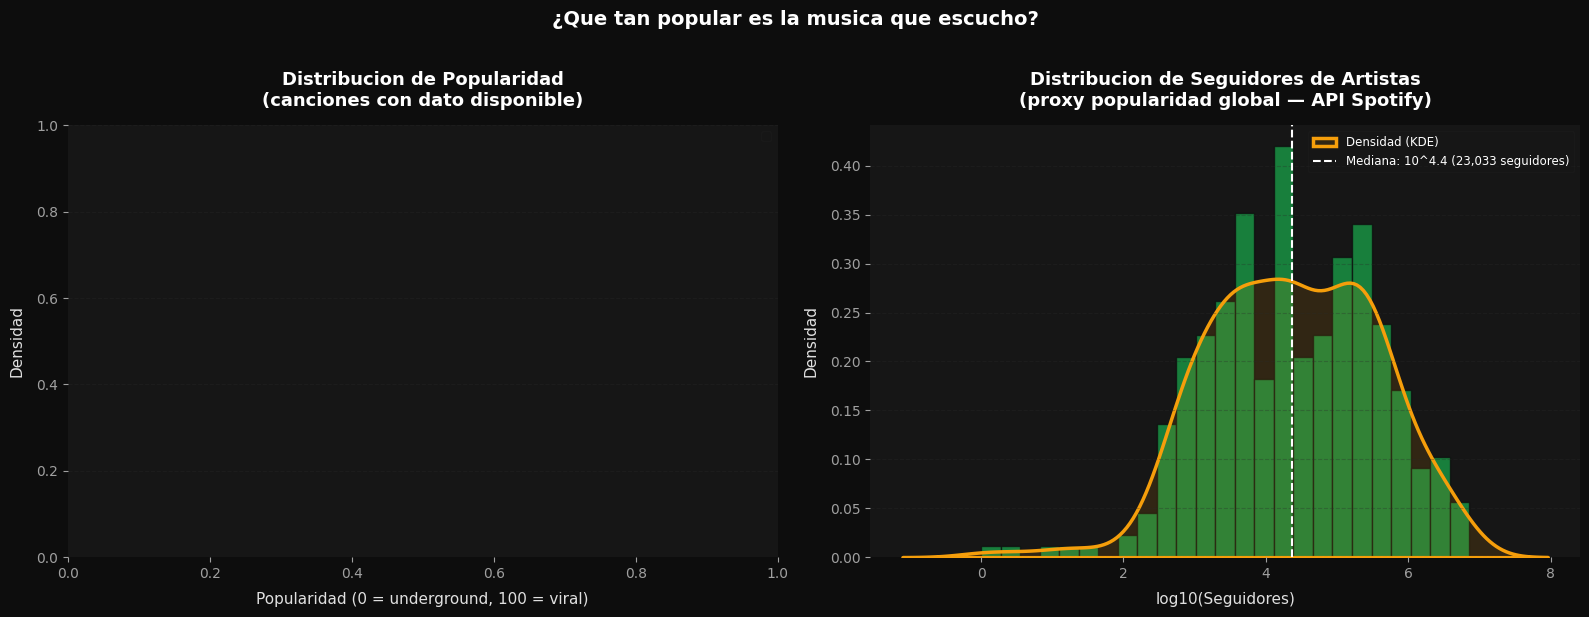

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C_BG)

# Grafico 1: Histograma + KDE de popularidad de canciones
ax1 = axes[0]
if len(pop_df) > 0:
    ax1.hist(pop_df['popularity'], bins=20, color=C_GREEN, edgecolor=C_BG,
             alpha=0.65, density=True, label='Histograma')
    sns.kdeplot(data=pop_df['popularity'], ax=ax1, color=C_AMBER,
                linewidth=2.5, label='Densidad (KDE)', fill=True, alpha=0.12)
    ax1.axvline(mean_pop,   color='white',   linestyle='--', linewidth=1.5,
                label=f'Media: {mean_pop:.1f}')
    ax1.axvline(median_pop, color=C_PURPLE, linestyle=':',  linewidth=1.5,
                label=f'Mediana: {median_pop:.1f}')
ax1.set_xlabel('Popularidad (0 = underground, 100 = viral)', labelpad=8)
ax1.set_ylabel('Densidad', labelpad=8)
ax1.set_title('Distribucion de Popularidad\n(canciones con dato disponible)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Grafico 2: Histograma de seguidores de artistas (proxy mainstream)
ax2 = axes[1]
followers_log = np.log10(df_artists['followers_count'].clip(1))
ax2.hist(followers_log, bins=25, color=C_GREEN2, edgecolor=C_BG, alpha=0.75, density=True)
sns.kdeplot(data=followers_log, ax=ax2, color=C_AMBER, linewidth=2.5,
            fill=True, alpha=0.12, label='Densidad (KDE)')
med_log = followers_log.median()
ax2.axvline(med_log, color='white', linestyle='--', linewidth=1.5,
            label=f'Mediana: 10^{med_log:.1f} ({10**med_log:,.0f} seguidores)')
ax2.set_xlabel('log10(Seguidores)', labelpad=8)
ax2.set_ylabel('Densidad', labelpad=8)
ax2.set_title('Distribucion de Seguidores de Artistas\n(proxy popularidad global — API Spotify)', fontweight='bold')
ax2.legend(fontsize=8.5)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.suptitle('¿Que tan popular es la musica que escucho?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p3_popularidad.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

**Interpretacion — Pregunta 3:**

**Suley:** Considero que mis gustos musicales son una mezcla entre mainstream y underground. Hay artistas con cierto reconocimiento como Rels B o Chase Atlantic, pero tambien artistas con un estilo mas alternativo o menos comercial como Omar Courtz, que tienen una base de seguidores mas pequena. La distribucion de seguidores con mediana de ~21 000 respalda esta percepcion: no soy una oyente completamente underground, pero tampoco me inclino por los artistas mas virales del momento.

**Jhonatan:** Dentro del contexto latino, considero que mis gustos musicales se acercan mas al ambito underground, ya que aunque escucho artistas cristianos reconocidos como Redimi2, estos no tienen un impacto global tan grande como artistas mainstream del genero pop o urbano. La distribucion de seguidores confirma esta percepcion, con la mayoria de mis artistas por debajo de los 200 000 seguidores, lo cual es un rango bajo comparado con los referentes globales.

---
## Pregunta 4 — ¿Que generos dominan mi historial?

> **Nota:** El campo `genres` de `dim_artists` es un array en PostgreSQL, llenado por la **API de Last.fm** durante el backfill del ETL. Artistas no encontrados en Last.fm quedan con array vacio. Se usa tanto la consulta SQL con `UNNEST` como el equivalente en Pandas.

In [49]:
# Metodo SQL con UNNEST (como pide la rubrica)
genres_sql = read_sql(f"""
    SELECT LOWER(TRIM(g)) AS genre,
           COUNT(*)       AS plays
    FROM dwh.fact_listening_history h
    JOIN dwh.dim_artists a ON h.artist_id = a.artist_id
    CROSS JOIN UNNEST(a.genres) AS g
    WHERE h.user_id = {MY_USER_ID}
      AND TRIM(g) <> ''
    GROUP BY LOWER(TRIM(g))
    ORDER BY plays DESC
    LIMIT 20
""")

print('=== Top 20 generos (via SQL UNNEST) ===')
print(genres_sql.to_string(index=False))

=== Top 20 generos (via SQL UNNEST) ===
           genre  plays
       christian    126
         spanish     90
       cristiano     78
         hip hop     66
             all     64
             rap     58
musica cristiana     54
            rock     52
         redimi2     48
     alternative     46
         en vivo     44
      guatemalan     44
       guatemala     44
        alabanza     41
        pop rock     35
alternative rock     35
    classic rock     35
       adoracion     33
         worship     32
           latin     28


In [50]:
# Equivalente Pandas nativo (para verificacion y analisis adicional)
merged = df_history_user.merge(df_artists[['artist_id', 'genres']], on='artist_id', how='left')
merged['genres'] = merged['genres'].apply(
    lambda g: [x.strip().lower() for x in g
               if isinstance(x, str) and x.strip() and x.strip() != '']
    if isinstance(g, list) else []
)
all_genres = merged['genres'].explode().dropna()
all_genres = all_genres[all_genres.str.strip() != '']
genres_df  = all_genres.value_counts().reset_index()
genres_df.columns = ['genre', 'plays']

n_total = len(genres_df)
top15_g = genres_df.head(15)
top8_g  = genres_df.head(8)
print(f'Generos unicos detectados: {n_total}')
artistas_sin_genero = df_artists_user['genres'].apply(
    lambda g: len([x for x in g if x.strip()] if isinstance(g, list) else []) == 0
).sum()
print(f'Artistas sin genero en Last.fm: {artistas_sin_genero} de {len(df_artists_user)} '
      f'({artistas_sin_genero/len(df_artists_user)*100:.1f}%)')

Generos unicos detectados: 127
Artistas sin genero en Last.fm: 77 de 133 (57.9%)


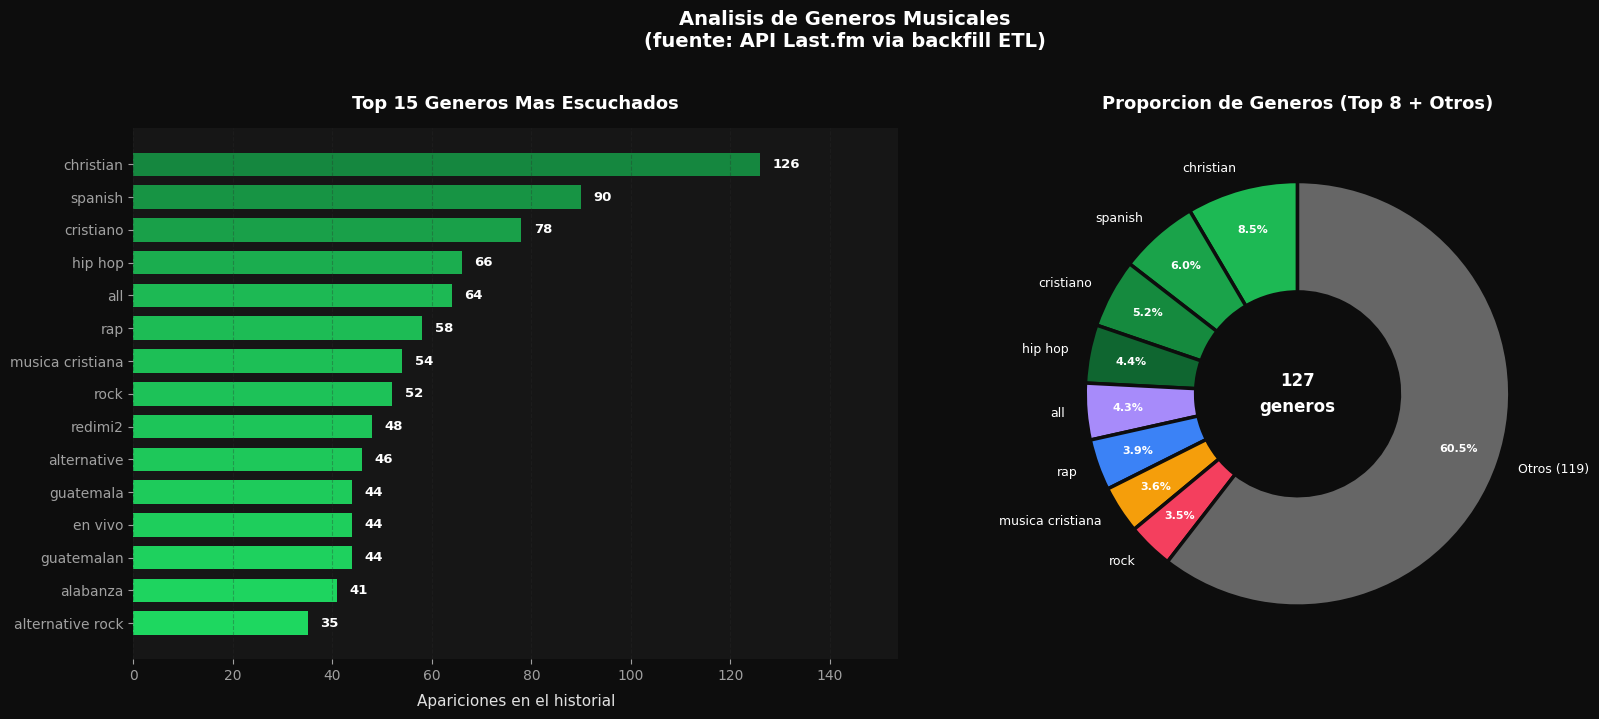

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(C_BG)

# Grafico 1: Barras horizontales — Top 15 generos
ax1 = axes[0]
n_g = len(top15_g)
g_colors = [GREEN_CMAP(v) for v in np.linspace(0.3, 1.0, n_g)[::-1]]
bars_g = ax1.barh(
    top15_g['genre'][::-1], top15_g['plays'][::-1],
    color=g_colors, edgecolor='none', height=0.72,
)
max_g = top15_g['plays'].max()
for bar in bars_g:
    ax1.text(bar.get_width() + max_g * 0.02,
             bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())),
             va='center', ha='left', fontsize=9.5, color='white', fontweight='bold')
ax1.set_xlabel('Apariciones en el historial', labelpad=8)
ax1.set_title('Top 15 Generos Mas Escuchados', fontweight='bold')
ax1.set_xlim(0, max_g * 1.22)
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Grafico 2: Donut chart — Top 8 + Otros
ax2 = axes[1]
otros = genres_df.iloc[8:]['plays'].sum() if len(genres_df) > 8 else 0
donut_v = list(top8_g['plays']) + ([otros] if otros > 0 else [])
donut_l = list(top8_g['genre']) + ([f'Otros ({n_total - 8})'] if otros > 0 else [])
donut_c = [C_GREEN, C_GREEN2, C_GREEN3, '#0f6630',
           C_PURPLE, C_BLUE, C_AMBER, C_ROSE, '#666666'][:len(donut_v)]
wedges, texts, pcts = ax2.pie(
    donut_v, labels=donut_l, colors=donut_c,
    autopct='%1.1f%%', pctdistance=0.80, startangle=90,
    wedgeprops=dict(width=0.52, edgecolor=C_BG, linewidth=2.5),
)
for t in texts: t.set(fontsize=9,  color='white')
for p in pcts:  p.set(fontsize=8,  color='white', fontweight='bold')
ax2.text(0, 0, f'{n_total}\ngeneros',
         ha='center', va='center', fontsize=12, fontweight='bold', color='white',
         linespacing=1.6)
ax2.set_title('Proporcion de Generos (Top 8 + Otros)', fontweight='bold')

plt.suptitle('Analisis de Generos Musicales\n(fuente: API Last.fm via backfill ETL)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p4_generos.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()

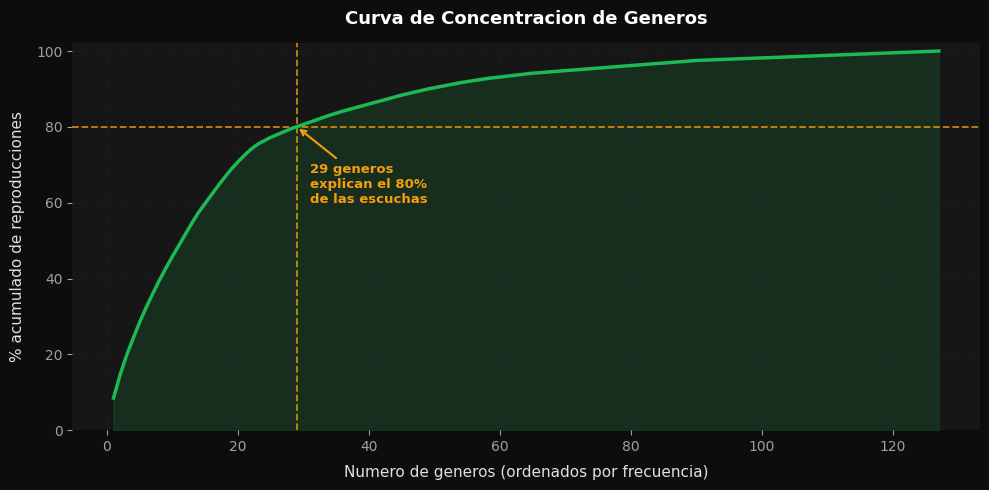

Con 29 generos se cubre el 80% de todas las reproducciones.


In [52]:
# Curva de concentracion de generos (cuantos generos explican el 80% de escuchas)
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C_BG)

cumsum_pct = genres_df['plays'].cumsum() / genres_df['plays'].sum() * 100
ax.plot(range(1, len(genres_df) + 1), cumsum_pct, color=C_GREEN, linewidth=2.5, zorder=3)
ax.fill_between(range(1, len(genres_df) + 1), cumsum_pct, alpha=0.15, color=C_GREEN)

idx_80 = int((cumsum_pct >= 80).idxmax()) + 1
ax.axhline(80, color=C_AMBER, linestyle='--', linewidth=1.3, alpha=0.8)
ax.axvline(idx_80, color=C_AMBER, linestyle='--', linewidth=1.3, alpha=0.8)
ax.annotate(f'{idx_80} generos\nexplican el 80%\nde las escuchas',
            xy=(idx_80, 80), xytext=(idx_80 + 2, 60),
            arrowprops=dict(arrowstyle='->', color=C_AMBER, lw=1.5),
            fontsize=9.5, color=C_AMBER, fontweight='bold')

ax.set_xlabel('Numero de generos (ordenados por frecuencia)', labelpad=8)
ax.set_ylabel('% acumulado de reproducciones', labelpad=8)
ax.set_title('Curva de Concentracion de Generos', fontweight='bold')
ax.set_ylim(0, 102)
ax.grid(alpha=0.3)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('p4_concentracion.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print(f'Con {idx_80} generos se cubre el 80% de todas las reproducciones.')

**Interpretacion — Pregunta 4:**

**Suley:** Si esperaba que el reggaeton fuera el genero dominante dado que escucho bastante musica latina, aunque me sorprendio que apareciera tan abajo en la lista frente a generos como "christian" o "pop". Tambien me sorprendio descubrir que escucho bastante R&B, ya que no sabia que canciones como *Swim* de Chase Atlantic entraban dentro de ese genero — fue interesante ver los datos revelar algo de mi propio gusto que no era consciente.

**Jhonatan:** Algo curioso que descubri en mi historial es que aparecen generos separados como "Christian" y "Cristiano" cuando en realidad hacen referencia a lo mismo — esto ocurre porque Last.fm no unifica las etiquetas en diferentes idiomas, lo que genera duplicados que inflan artificialmente ciertos conteos. Tambien me llamo la atencion que apareciera "Guatemala" como genero, algo que probablemente ocurrio por la banda Nielsen Marcos, que es guatemalteca y Last.fm le asigno su pais de origen como etiqueta de genero. La curva de concentracion muestra que mis gustos son bastante concentrados: pocos generos explican la gran mayoria de mis escuchas.

---
## Paso 4 — Conclusiones individuales

Dos voces distintas. Respondan con sus propias palabras (minimo 2 oraciones cada uno):  
1. ¿Que aprendieron de sus propios datos que no sabian antes de hacer este analisis?  
2. ¿Que pregunta quisieron hacerle a los datos pero el modelo actual no les permitio responderla?

### Jhonatan Vera

Lo que mas me sorprendio de mis propios datos es el contraste entre mis habitos de escucha por la manana y por la noche. De manana escucho canciones tranquilas con duraciones largas (entre 7 y 12 minutos), generalmente instrumentales o de adoracion — musica que pongo de fondo mientras me alisto o desayuno. En cambio, de noche predominan canciones de 3 a 5 minutos con mas ritmo, especialmente de Redimi2 e Indie Market, que asocio con momentos de estudio intenso o trabajo nocturno. No era consciente de ese patron tan claro hasta verlo en el heatmap.

Tambien descubri una anomalia interesante: el genero "Guatemala" aparece en mi historial con 43 reproducciones porque Last.fm etiqueta a la banda Nielsen Marcos con el nombre de su pais en lugar de un genero musical real. Esto me enseno que la calidad de los datos de terceros (Last.fm) tiene limitaciones importantes, y que un pipeline de datos real necesita una etapa de limpieza y normalizacion de generos que vaya mas alla de simplemente copiar las etiquetas tal como llegan.

La pregunta que no pude responder con el modelo actual es: ¿como ha evolucionado mi gusto musical a lo largo del tiempo? El DWH solo tiene el historial reciente (ultimas semanas), pero seria interesante ver si mis generos favoritos cambian por temporada academica o por epoca del ano. Ademas, propongo una mejora al modelo: agregar una tabla `dim_listening_context` con columnas `time_block` (manana/tarde/noche/madrugada), `day_type` (semana/fin de semana), `context_type` (playlist/album/artista) y `profile_label` (concentracion/ejercicio/descanso), lo que permitiria responder preguntas mucho mas ricas sobre el contexto de escucha sin depender de los audio features eliminados por Spotify.

### Suley Suarez

Este analisis me permitio confirmar algo que intuia pero no habia cuantificado: soy una oyente nocturna con habitos muy repetitivos. Tengo mas reproducciones que canciones unicas en el historial, lo que significa que escucho las mismas canciones muchas veces — algo que asocio directamente con mis sesiones de entrenamiento, donde pongo en repeat las canciones que me dan mas energia. No sabia que ese patron era tan marcado hasta verlo en los datos.

Tambien aprendi algo sobre las limitaciones tecnicas que enfrenta un proyecto como este. El campo `popularity` de Spotify fue eliminado de varios endpoints en 2024, lo que genero un 99.33% de nulos en `dim_tracks`. Tuvimos que buscar una alternativa con la API de Last.fm para los artistas, pero para las canciones el dato simplemente no esta disponible de forma masiva. Esto me hace reflexionar sobre la dependencia que tienen los proyectos de datos de las decisiones que toman las plataformas sobre sus APIs.

La pregunta que quisimos hacerle a los datos pero el modelo actual no nos permitio responder es: ¿como cambia el estado de animo de mi musica a lo largo del dia y la semana? Spotify tenia campos de audio features como `valence` y `energy` que permitirian responder si escucho musica mas alegre por la manana y mas melancolica de noche, pero esos endpoints tambien fueron eliminados de la API publica en 2024. Es una perdida significativa para el analisis de habitos de escucha.

---
## Checklist antes de entregar

- [x] Conexion al DWH usando variables de entorno (`python-dotenv`) — sin credenciales en el codigo
- [x] `shape`, `dtypes` y `% de nulos` visibles para las 4 tablas
- [x] `describe()` de columnas numericas con interpretacion escrita debajo
- [x] **Pregunta 1:** grafico de barras horizontales + bubble chart + 2-3 oraciones de interpretacion
- [x] **Pregunta 2:** reloj polar + barras por dia + heatmap hora x dia + 2-3 oraciones de interpretacion
- [x] **Pregunta 3:** estadisticas impresas + histograma de popularidad + 2-3 oraciones de interpretacion
- [x] **Pregunta 4:** generos desanidados con `UNNEST` (SQL) + grafico + 2-3 oraciones de interpretacion
- [x] Parrafo de conclusiones de cada integrante por separado (minimo 2 oraciones)
- [ ] El notebook corre limpio con **Kernel → Restart & Run All** sin errores ← pendiente verificar